# **Mentoring 2** - Credit Scoring and Analytics
Sekolah Data - Pacmann

In [63]:
# Load data manipulation package
import numpy as np
import pandas as pd

# Load data visualization package
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.covariance import log_likelihood

In [64]:
PATH_DATA = 'credit_risk_dataset.csv'

---
**Mentoring 2 to assess your understanding of these topics**:
1. Descriptive Statistics
2. Contingency Table and Probability Structure
3. Test of Independence
4. Odds and Odds Ratio
5. Likelihood Function and MLE
6. Optimization of Log Loss
7. Logistic Model Interpretation

# **Case 1**: Loan Applicant Analysis

This dataset contains information on loan applicants, including demographic details, financial status, loan characteristics, and credit history. It helps analyze factors affecting loan approval and default risk.

🔗 [Download dataset here](https://drive.google.com/file/d/1hw1WIjoe0HVABe5bMfa27yrOqv-JhD3q/view?usp=sharing)

---

### **Data Preparation**:

In [65]:
# Import dataset from csv file
data = pd.read_csv(PATH_DATA)

# Table check
data

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [66]:
# Information check
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [67]:
data["person_emp_length"].value_counts()

person_emp_length
0.0      4105
2.0      3849
3.0      3456
5.0      2946
1.0      2915
4.0      2874
6.0      2666
7.0      2196
8.0      1687
9.0      1367
11.0      740
10.0      696
12.0      575
13.0      426
14.0      335
15.0      238
16.0      165
17.0      129
18.0      104
19.0       64
20.0       42
21.0       38
22.0       19
24.0       10
23.0       10
25.0        8
26.0        6
27.0        5
31.0        4
28.0        3
123.0       2
30.0        2
41.0        1
34.0        1
29.0        1
38.0        1
Name: count, dtype: int64

## Split Train-Test Data

In [68]:
response_variable = "loan_status"

y = data[response_variable]
X = data.drop(columns=[response_variable], axis=1)

print('y shape : ', y.shape)
print('X shape : ', X.shape)

y shape :  (32581,)
X shape :  (32581, 11)


In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Validate splitting
print('X train shape :', X_train.shape)
print('y train shape :', y_train.shape)
print('X test shape  :', X_test.shape)
print('y test shape  :', y_test.shape)

print(y_train.value_counts(normalize = True))
print(y_test.value_counts(normalize = True))

X train shape : (26064, 11)
y train shape : (26064,)
X test shape  : (6517, 11)
y test shape  : (6517,)
loan_status
0    0.782727
1    0.217273
Name: proportion, dtype: float64
loan_status
0    0.778272
1    0.221728
Name: proportion, dtype: float64


In [70]:
data_train = pd.concat((X_train, y_train), axis=1)

#### **Question 1**:
Describe the type of data and measurement scale of each variable.

e.g. :
```
| Column                | Type of Data | Measurement Scale |
|-----------------------|--------------|-------------------|
| ID                    | Numerical    | Nominal           |
| AGE                   | Numerical    | Continuos         |
...
```

---

| Column                     | Type of Data | Measurement Scale |
|----------------------------|--------------|-------------------|
| person_age                 | Numerical    | Discrete          |
| person_income              | Numerical    | Discrete          |
| person_home_ownership      | Categorical  | Nominal           |
| person_emp_length          | Numerical    | Discrete          |
| loan_intent                | Categorical  | Nominal           |
| loan_grade                 | Categorical  | Ordinal           |
| loan_amnt                  | Numerical    | Discrete          |
| loan_int_rate              | Numerical    | Continuous        |
| loan_status                | Numerical    | Discrete          |
| loan_percent_income        | Numerical    | Continuous        |
| cb_person_default_on_file  | Categorical  | Nominal           |
| cb_person_cred_hist_length | Numerical    | Discrete          |

### **Question 2**:
Make a descriptive statistics and visualization of each variable.

---

**1. person_home_ownership**
- What types of home ownership historically get loan credit more?

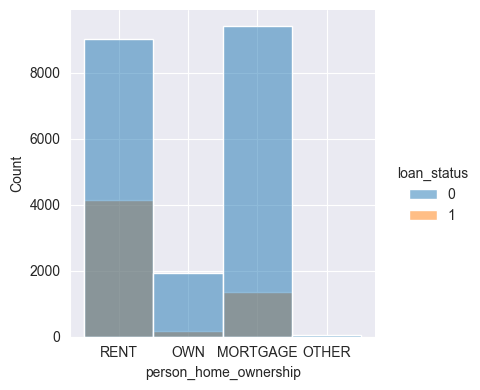

In [71]:
# Answer Here
import seaborn as sns

_ = sns.displot(data=data_train, x="person_home_ownership", hue="loan_status", height=4)

Berdasarkan distribution plot di atas, maka tipe home ownership "Mortgage" memiliki jumlah peminjaman terbanya

### Answer Here
Berdasarkan distribution plot di atas, maka tipe home ownership "Rent" memiliki jumlah peminjaman terbanya

**2. Age**
- What is the average and median age of the customer?

In [72]:
average_age = data_train["person_age"].mean()
median_age = data_train["person_age"].median()

print(f"Rata-rata usia customer : {average_age}")
print(f"Median usia customer : {median_age}")

Rata-rata usia customer : 27.76469459791283
Median usia customer : 26.0


- Visualize the variation in the buyer's age compared loan_status.
- What can you conclude?

Text(0, 0.5, 'Age')

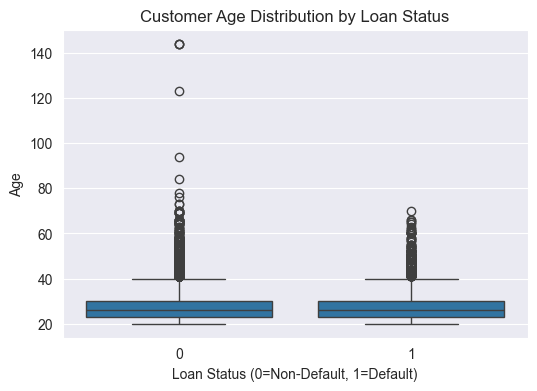

In [73]:
plt.figure(figsize=(6, 4))
_ = sns.boxplot(data=data_train, x='loan_status', y='person_age')
plt.title('Customer Age Distribution by Loan Status')
plt.xlabel('Loan Status (0=Non-Default, 1=Default)')
plt.ylabel('Age')

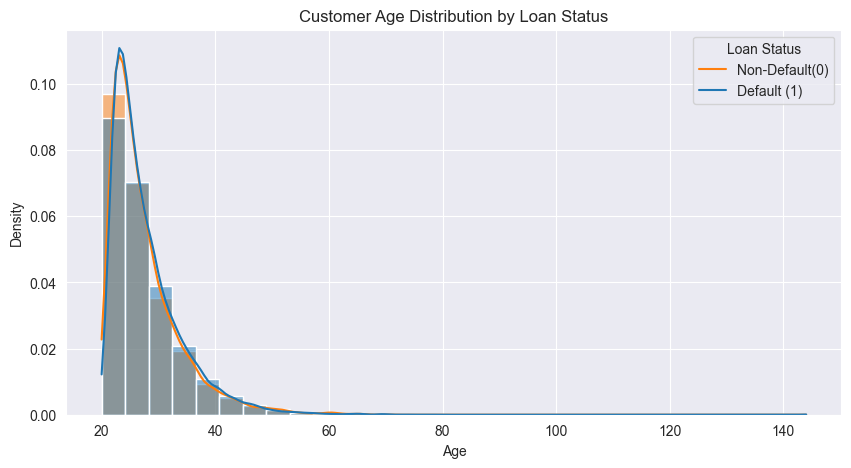

In [74]:
plt.figure(figsize=(10, 5))
_ = sns.histplot(data=data_train, x='person_age', hue='loan_status', bins=30, kde=True, stat='density', common_norm=False)
plt.title('Customer Age Distribution by Loan Status')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Loan Status', labels=['Non-Default(0)', 'Default (1)'])
plt.show()

In [75]:
data_train['person_age'].groupby(data_train['loan_status']).describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,20401.0,27.839273,6.425516,20.0,23.0,26.0,30.0,144.0
1,5663.0,27.496027,6.265323,20.0,23.0,26.0,30.0,70.0


---
** Kesimpulan **
1. Tidak ada perbedaan signifikan untuk usia antara group default dan non default
2. Terdapat outliers untuk customer dengan usia > 60 tahun
3. Customer paling muda berusia 20 tahun

**3. person_income**
- What is the average and distribution of person_income?

In [76]:
# Answer Here
average_income = data_train['person_income'].mean()
median_income = data_train['person_income'].median()
std_income = data_train['person_income'].std()

print(f'Average Income : {average_income}')
print(f'Median Income : {median_income}')
print(f'Standard Deviation of Income : {std_income}')

Average Income : 66171.84384591774
Median Income : 55000.0
Standard Deviation of Income : 63599.33247589088


- Visualize the variation in the person_income compared between default and non default
- What can you conclude?

Text(0, 0.5, 'Person Income')

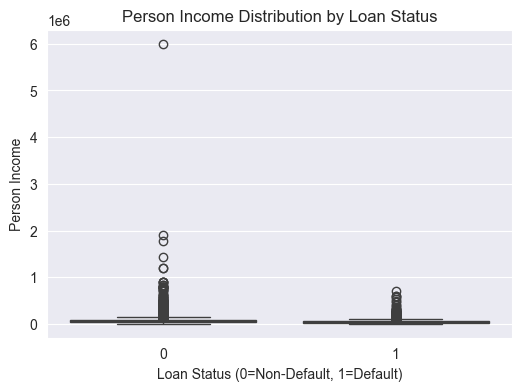

In [77]:
plt.figure(figsize=(6, 4))
_ = sns.boxplot(data=data_train, x='loan_status', y='person_income')
plt.title('Person Income Distribution by Loan Status')
plt.xlabel('Loan Status (0=Non-Default, 1=Default)')
plt.ylabel('Person Income')

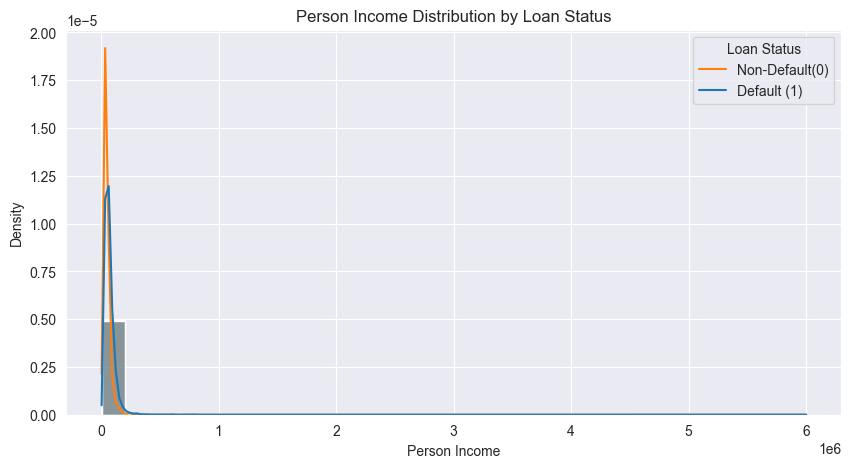

In [78]:
plt.figure(figsize=(10, 5))
_ = sns.histplot(data=data_train, x='person_income', hue='loan_status', bins=30, kde=True, stat='density', common_norm=False)
plt.title('Person Income Distribution by Loan Status')
plt.xlabel('Person Income')
plt.ylabel('Density')
plt.legend(title='Loan Status', labels=['Non-Default(0)', 'Default (1)'])
plt.show()

In [79]:
data_train.groupby('loan_status')['person_income'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,20401.0,70898.292143,68441.735152,7000.0,42000.0,60000.0,84600.0,6000000.0
1,5663.0,49144.778386,37032.454784,4000.0,30000.0,42000.0,59667.5,703800.0


*** Kesimpulan ***
Berdasarkan tabel diatas, terdapat perbedaan nilai rata-rata untuk income antara credit default dan non-default sebagai berikut :
1. Non-Default = 70.898,2
2. Default = 49.144, 7
Untuk customer yang creditnya default, mereka memiliki kecenderungan pendapatan yang lebih kecil dari customer yang incomenya non-default.

### **Question 3**:
What is the probability of a customer default, given they are under 30 years old?

In [80]:
customers_under_30 = data_train[data_train['person_age'] < 30]
default_customers_under_30 = customers_under_30[customers_under_30['loan_status'] == 1]

probabilities = len(default_customers_under_30) / len(customers_under_30)

print(f'Probabilities of default customer under 30 : {probabilities:.4f}')

Probabilities of default customer under 30 : 0.2225


What is the probability of a customer default, given the loan_percent_income > half of the income ? Interpret the result

In [81]:
customers_over_half_income = data_train[data_train['loan_percent_income'] > 0.5]
default_customers_over_half_income = customers_over_half_income[customers_over_half_income['loan_status'] == 1]

probabilities = len(default_customers_over_half_income) / len(customers_over_half_income)

print(f"Probabilities of default customer with loan percent income > 50%: {probabilities}")

Probabilities of default customer with loan percent income > 50%: 0.7823834196891192


What is the probability of a customer default, given the loan_int_rate > 10% ? Interpret the result

In [82]:
customers_interest_rate_over_10 = data_train[data_train["loan_int_rate"] > 10.0]
default_customers_interest_rate_over_10 = customers_interest_rate_over_10[customers_interest_rate_over_10['loan_status'] == 1]

probabilities = len(customers_interest_rate_over_10) / len(default_customers_interest_rate_over_10)

print(f"Probabilities of default customer with loan interest rate over 10% : {probabilities}")

Probabilities of default customer with loan interest rate over 10% : 3.4518787878787878


### **Question 4**:
From a sample of customers, construct a two way contingency table based on their cb_person_default_on_file and loan_status.

In [83]:
# Answer Here
contingency_table = pd.crosstab(data_train["cb_person_default_on_file"], data_train["loan_status"])
contingency_table

loan_status,0,1
cb_person_default_on_file,,
N,17563,3951
Y,2838,1712


What is the probability of each cb_person_default_on_file default?

In [84]:
default_table = contingency_table[1] / contingency_table.sum(axis=1)
default_table

cb_person_default_on_file
N    0.183648
Y    0.376264
dtype: float64

### **Question 5**:
What is the probability of each person_home_ownership (Rent and Mortgage) default?

**Default n Mortgage**

In [85]:
ownership_contingency_table = pd.crosstab(data_train["person_home_ownership"], data_train["loan_status"])
ownership_contingency_table

loan_status,0,1
person_home_ownership,,
MORTGAGE,9423,1336
OTHER,58,25
OWN,1913,159
RENT,9007,4143


In [86]:
default_mortgage = ownership_contingency_table.loc["MORTGAGE", 1] / ownership_contingency_table.loc["MORTGAGE"].sum()
print(f"DEFAULT rate of MORTGAGE : {default_mortgage:.4f}")

DEFAULT rate of MORTGAGE : 0.1242


**Default n Rent**

In [87]:
default_rent = ownership_contingency_table.loc["RENT", 1] / ownership_contingency_table.loc["RENT"].sum()
print(f"DEFAULT rate of RENT : {default_rent:.4f}")

DEFAULT rate of RENT : 0.3151


### **Question 6**:
Conduct a $\chi^{2}$ test of independence between default (loan status)
and loan_intent. Use $\alpha=0.05$.

State the hypotheses:
- $\text H_{0}:$ The default probability is independent of customer's loan_intent.
- $\text H_{1}:$ The default probability is not independent of customer's loan_intent.

In [88]:
# Conduct a chi-square test of independence between loan default (loan_status) and loan intent (loan_intent)
from scipy.stats import chi2_contingency

# Create a contingency table for all loan intents
contingency_all = pd.crosstab(data_train['loan_intent'], data_train['loan_status'])

# Perform the chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_all)

print('Contingency table')
print(contingency_all)
print()
print('Expected frequencies:')
print(expected)
print()
print('Chi-square statistic:')
print(chi2)
print()
print('p-value:')
print(p)
print()
print('Degrees of freedom:')
print(dof)
print()
if p < 0.05:
    print("Reject H0: The default probability is not independent of customer's loan_intent")
else:
    print("Accept H0: The default probability is independent of customer's loan_intent")

Contingency table
loan_status           0     1
loan_intent                  
DEBTCONSOLIDATION  3013  1203
EDUCATION          4244   900
HOMEIMPROVEMENT    2155   730
MEDICAL            3570  1273
PERSONAL           3548   888
VENTURE            3871   669

Expected frequencies:
[[3299.97759362  916.02240638]
 [4026.34837324 1117.65162676]
 [2258.16777931  626.83222069]
 [3790.74750614 1052.25249386]
 [3472.17756292  963.82243708]
 [3553.58118478  986.41881522]]

Chi-square statistic:
387.98723671132365

p-value:
1.1509082343456062e-81

Degrees of freedom:
5

Reject H0: The default probability is not independent of customer's loan_intent


### **Question 7**:
What is the odds ratio of default between `DEBTCONSOLIDATION` and `HOMEIMPROVEMENT`?

In [89]:
contingency_table_loan_intent = pd.crosstab(data_train["loan_intent"], data_train[response_variable])
contingency_table_loan_intent

loan_status,0,1
loan_intent,,
DEBTCONSOLIDATION,3013,1203
EDUCATION,4244,900
HOMEIMPROVEMENT,2155,730
MEDICAL,3570,1273
PERSONAL,3548,888
VENTURE,3871,669


In [90]:
debt_cons_default = contingency_table_loan_intent.loc["DEBTCONSOLIDATION", 1]
debt_cons_non_default = contingency_table_loan_intent.loc["DEBTCONSOLIDATION", 0]

home_imp_default = contingency_table_loan_intent.loc["HOMEIMPROVEMENT", 1]
home_imp_non_default = contingency_table_loan_intent.loc["HOMEIMPROVEMENT", 0]

odds_debt_cons = debt_cons_default / debt_cons_non_default
odds_home_imp = home_imp_default / home_imp_non_default
odds_ratio = odds_debt_cons / odds_home_imp

print(f"Odds ration between DEBTCONSOLIDATION:HOMEIMPROVEMENT : {odds_ratio:.4f}")

Odds ration between DEBTCONSOLIDATION:HOMEIMPROVEMENT : 1.1787


### **Question 8**:
what can you conclude about the relationship between default with these variables:

- `person_home_ownership`
- `loan_intent`
- `cb_person_default_on_file`

What evidence do you have? Are they good predictors for loan_status? Explain.

In [91]:
columns = ["person_home_ownership", "loan_intent", "cb_person_default_on_file"]
crosstab_list = []

for col in columns:
    crosstab = pd.crosstab(data_train[col], data_train[response_variable], margins=True)
    crosstab_list.append(crosstab)

In [92]:
crosstab_list[0][0]['All']

np.int64(20401)

In [93]:
WOE_list = []
IV_list = []

for crosstab in crosstab_list:
    crosstab['p_good'] = crosstab[0] / crosstab[0]['All']
    crosstab['p_bad'] = crosstab[1] / crosstab[1]['All']
    crosstab['WOE'] = np.log(crosstab['p_good'] / crosstab['p_bad'])
    crosstab['contribution'] = (crosstab['p_good'] - crosstab['p_bad']) * crosstab['WOE']

    IV = crosstab['contribution'][:-1].sum()
    added_IV = {
        'characteristic': crosstab.index.name,
        'Information Value': IV,
    }
    IV_list.append(added_IV)

    WOE_list.append(crosstab)

In [94]:
IV_table = pd.DataFrame(IV_list)
IV_table

,characteristic,Information Value
0,person_home_ownership,0.378239
1,loan_intent,0.089566
2,cb_person_default_on_file,0.160981


In [95]:
strength = []

for iv in IV_table['Information Value']:
    if iv < 0.02:
        strength.append('Unpredictive')
    elif 0.02 <= iv < 0.1:
        strength.append('Weak')
    elif 0.1 <= iv < 0.3:
        strength.append('Medium')
    else:
        strength.append('Strong')

IV_table = IV_table.assign(strength=strength)
IV_table.sort_values(by='Information Value')

,characteristic,Information Value,strength
1,loan_intent,0.089566,Weak
2,cb_person_default_on_file,0.160981,Medium
0,person_home_ownership,0.378239,Strong


In [96]:
strength = []

for iv in IV_table['Information Value']:
    if iv < 0.02:
        strength.append('Unpredictive')
    elif 0.02 <= iv < 0.1:
        strength.append('Weak')
    elif 0.1 <= iv < 0.3:
        strength.append('Medium')
    else:
        strength.append('Strong')

IV_table = IV_table.assign(strength=strength)
IV_table.sort_values(by='Information Value')

,characteristic,Information Value,strength
1,loan_intent,0.089566,Weak
2,cb_person_default_on_file,0.160981,Medium
0,person_home_ownership,0.378239,Strong


In [97]:
# Create a funtion to plot the WOE
def plot_WOE(crosstab):
    """
    Function to plot the WOE trend.

    Parameters
    ----------
    crosstab : DataFrame
    The cross tabulation of the characteristic.

    """
    # Define the plot size
    plt.figure(figsize = (8,4))

    # Plot the WOE
    sns.pointplot(x = crosstab[:-1].T.columns,
                y = 'WOE',
                data = crosstab[:-1],
                markers = 'o',
                linestyles = '--',
                color = 'blue')

    # Rotate the label of x-axis
    plt.xticks(rotation = 20)

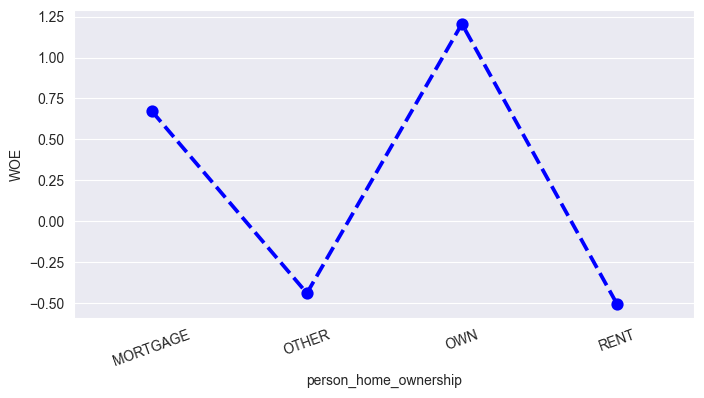

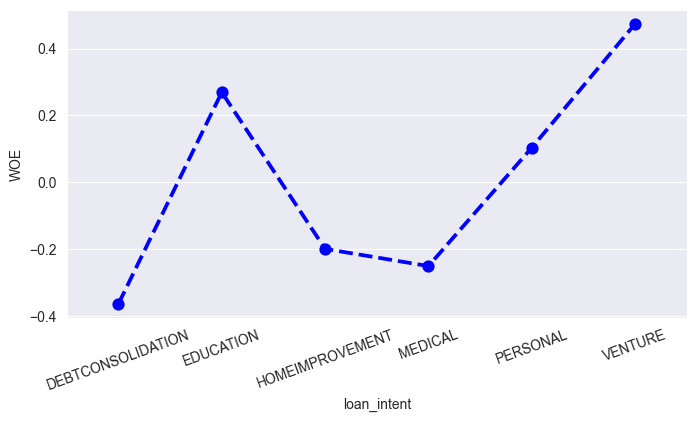

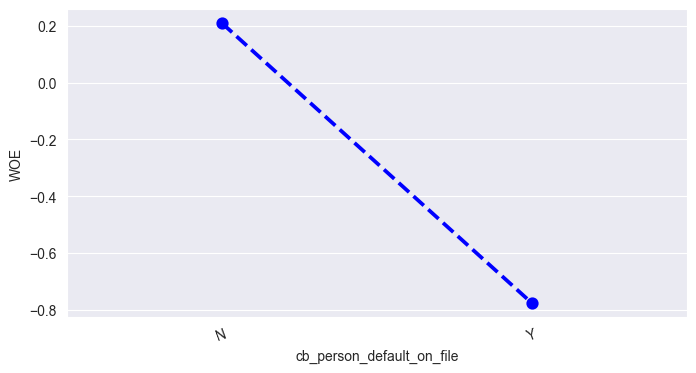

In [98]:
for crosstab in crosstab_list:
    plot_WOE(crosstab)

In [99]:
# Import the libraries
import scipy.stats as stats
from scipy.stats import chi2_contingency

# Create a function of independence test
def independence_test(data, characteristic_label, alpha=0.05):
    """
    Funtion to perform the independence test.

    Parameters
    ----------
    data : array like
      The name of dataset.

    characteristic_label : object
      The label of characteristic variable.

    alpha : float in range[0,1], default = 0.05
      Probability of Type I Error (reject H0 when H0 is true).

    Return
    ------
    res : dataframe
      The summary result of the independence test.

    """
    # Build the contingency table
    crosstab = pd.crosstab(data[characteristic_label],
                           data[response_variable],
                           margins = False)

    # Test whether churn is independent of the predictor
    stats.chi2_contingency(crosstab)

    # Result of independence test
    result = stats.chi2_contingency(crosstab)

    # Extract the test result
    stat = result[0]
    pval = result[1]

    # Print the conclusion
    if pval < alpha:
        conclusion = 'Not Independent'
    else:
        conclusion = 'Independent'

    # Tabulate the results
    res = pd.DataFrame({'Characteristic': characteristic_label,
                        'Chi-stat': round(stat,2),
                        'P-value': pval,
                        'Conclusion': conclusion},
                       index=[0])

    return res

In [100]:
characteristic_list = IV_table['characteristic']

In [101]:
ind_table = pd.DataFrame({'Characteristic': [],
                        'Chi-stat': [],
                        'P-value': [],
                        'Conclusion': []})

# Perform independence test for all characteristics
for characteristic in characteristic_list:

  # Perform the independence test
  test_result = independence_test(data = data_train,
                                  characteristic_label = characteristic,
                                  alpha = 0.05)

  # Append test result to the table
  ind_table = pd.concat((ind_table, test_result),
                        axis = 0,
                        ignore_index = True)

In [102]:
ind_table

,Characteristic,Chi-stat,P-value,Conclusion
0,person_home_ownership,1531.73,0.000000e+00,Not Independent
1,loan_intent,387.99,1.150908e-81,Not Independent
2,cb_person_default_on_file,818.20,5.959476e-180,Not Independent


## **Case 2**: Logistic Regression

## **Data Preparation**:

In [103]:
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [104]:
# Filter dataset
# We will only use 2 variables: loan_percent_income and loan_status

df = data[['loan_percent_income','loan_status']].copy()
df.head()

,loan_percent_income,loan_status
0,0.59,1
1,0.10,0
2,0.57,1
3,0.53,1
4,0.55,1


In [105]:
# Information check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   loan_percent_income  32581 non-null  float64
 1   loan_status          32581 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 509.2 KB


- Check for missing value before analysis.
- Then perform a simple imputation.

In [106]:
# Checking missing value
df.isnull().sum()

loan_percent_income    0
loan_status            0
dtype: int64

- There are no missing values on `loan_percent_income    ` (a numerical variable)

## **Question 1**:
Construct the likelihood function for those 32581 credit customers. Make it in latex markdown

$$
\mathcal{L} = \prod_{i=1}^{n}\pi(x_{i})^{y_{i}}[1-\pi(x_{i})]^{(1-y_{i})}
$$
- If $y_i=1$, customer i defaulted, 0 otherwise:
- $\pi(x_{i})$ = Probability of default for customer ${i}$
$$
$$

## **Question 2**:
Make a plot of likelihood/log-likelihood value for each estimate of $\pi(x)$, where $\pi(x)$ in range [0.1, 0.9]. At which $\pi(x)$ the likelihood function takes its maximum value? Explain.

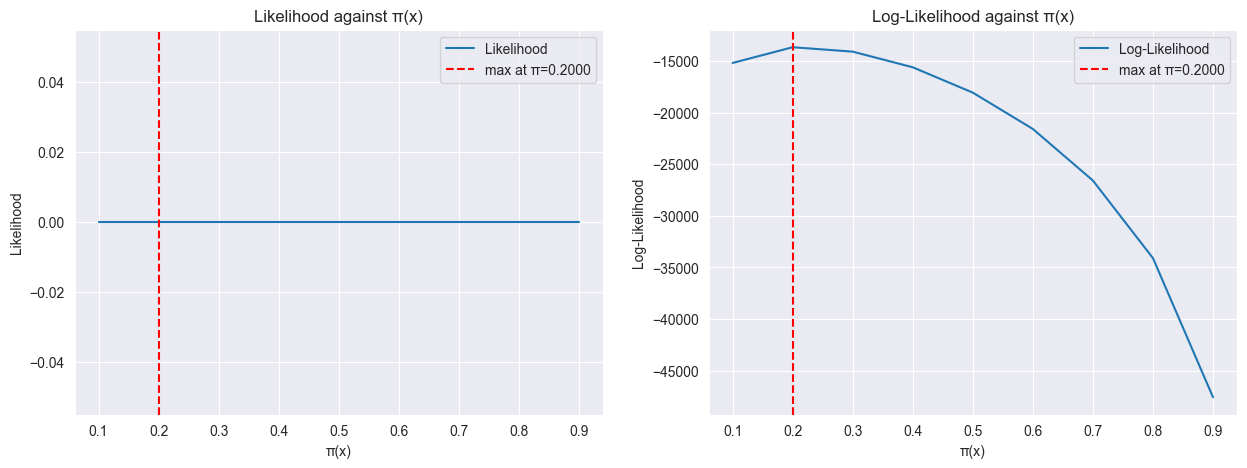

In [139]:
y = data_train['loan_status'].values
n = len(y)

pi_list = np.arange(0.1, 1, 0.1)

likelihood_list = []
log_likelihood_list = []

for pi in pi_list:
    ll = np.sum(y * np.log(pi) + (1 - y ) * np.log(1 - pi))
    log_likelihood_list.append(ll)
    likelihood_list.append(np.exp(ll))

max_idx = np.argmax(log_likelihood_list)
max_pi = pi_list[max_idx]

plt.figure(figsize = (15, 5))
plt.subplot(1, 2, 1)
plt.plot(pi_list, likelihood_list, label="Likelihood")
plt.xlabel('π(x)')
plt.ylabel('Likelihood')
plt.title('Likelihood against π(x)')
plt.axvline(x=max_pi, color='r', linestyle='--', label=f'max at π={max_pi:.4f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(pi_list, log_likelihood_list, label="Log-Likelihood")
plt.xlabel('π(x)')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood against π(x)')
plt.axvline(x=max_pi, color='r', linestyle='--', label=f'max at π={max_pi:.4f}')
plt.legend()

plt.show()


## **Question 3**:
Use logistic regression to model the effect of loan_percent_incomeon the probability
of default.

In [140]:
from sklearn.linear_model import LogisticRegression

X = data_train[['loan_percent_income']]
y = data_train['loan_status']

log_reg = LogisticRegression().fit(X, y)

print(f'Intercept: {log_reg.intercept_[0]}')
print(f'Coefficient: {log_reg.coef_[0][0]}')

Intercept: -2.8881433516707298
Coefficient: 8.341499523966489


## **Question 4**:
Describe the estimated effect loan_percent_income on the odds of default.

In [112]:
# Answer Here

coefficient = log_reg.coef_[0][0]
odds_ratio = np.exp(coefficient)

print(f'Estimated effect : For each 1 unit increase in loan_percent_income, the odds default multiply by {odds_ratio:.4f} times')

Estimated effect : For each 1 unit increase in loan_percent_income, the odds default multiply by 4194.3746 times


## **Question 5**:
At what loan percent income does the estimated probability of default equal 0.50? At that loan percent income, give a linear approximation

In [118]:
intercept = log_reg.intercept_[0]
coefficient = log_reg.coef_[0][0]

loan_percent_income_50 = -intercept / coefficient

print(f'Estimated loan_percent_income when probability of default is 50% : {loan_percent_income_50:.5f}')
print(f'Linear Approximation: {intercept:.5f} + {coefficient:.5f} * loan_percent_income')

Estimated loan_percent_income when probability of default is 50% : 0.34624
Linear Approximation: -2.88814 + 8.34150 * loan_percent_income


## **Question 6**:
Test the hypothesis that loan_percent_income has no effect to probability of default.

In [128]:
test_result = independence_test(
    data=data_train, characteristic_label='loan_percent_income', alpha=0.05
)

if test_result['P-value'][0] < 0.05:
    print('Reject H0 : loan_percent_income has a significant effect on probability of default.')
else:
    print('Fail to reject H0 : loan_percent_income does not have a significant effect on probability of default.')


Reject H0 : loan_percent_income has a significant effect on probability of default.


## **Question 7**:
Use logistic regression to model the effect of **standardized loan_percent_income** on the probability
of default

In [135]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_loan_percent_income = scaler.fit_transform(data_train[['loan_percent_income']])

log_reg = LogisticRegression().fit(X_loan_percent_income, y)

b1_transform = pd.Series(log_reg.coef_[0], index =['loan_percent_income'])
b1_transform

loan_percent_income    0.913164
dtype: float64

## **Question 8**:
Based on the parameter estimate of standardized loan percent income, describe the estimated effect of **loan percent income** on the odds of default.

In [136]:
odds_ratio_std = np.exp(b1_transform.values[0])
print(f'For every 1 unit increase loan_percent_income, the odds of default multiply by {odds_ratio_std:.4f} times')

For every 1 unit increase loan_percent_income, the odds of default multiply by 2.4922 times


## **Question 9**:
Based on the parameter estimate of standardized annual mileage, describe the estimated effect of **annual loan percent income** on the odds of default.

In [137]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_loan_percent_income = scaler.fit_transform(data_train[['loan_percent_income']])

log_reg = LogisticRegression().fit(X_loan_percent_income, y)

b1_transform = pd.Series(log_reg.coef_[0], index =['loan_percent_income'])
odds_ratio_std = np.exp(b1_transform.values[0])

print(f'For every 1 unit increase loan_percent_income, the odds of default multiply by {odds_ratio_std:.4f} times')

For every 1 unit increase loan_percent_income, the odds of default multiply by 2.4922 times
